# Phase 1 — Project Setup and Data Inspection

## Flood Susceptibility Analysis of the Gomti River–Influenced Lucknow Region

### Objective

This notebook establishes the Python environment and performs an initial
inspection of the spatial datasets prepared for Phase 1.

The main objectives are:

1. Verify the Python geospatial environment.
2. Load the prepared vector datasets.
3. Inspect their geometry, coordinate reference system (CRS), feature count,
   spatial extent, and attributes.
4. Confirm that the datasets are spatially compatible before further analysis.

### Study Context

The study focuses on the Gomti River–influenced region around Lucknow,
with temporal analysis planned for:

- 2003
- 2014
- 2025

The current stage focuses only on preparing and validating the study-area
spatial data.

## 1. Import Required Python Libraries

We begin by importing the libraries required for vector-data inspection.

GeoPandas is used for vector geospatial data such as Shapefiles and GeoJSON.
Pandas is used for tabular data, NumPy for numerical operations, and
Matplotlib for visualization.

In [7]:
import sys
print(sys.executable)

d:\Projects\GeoAI-Flood-Susceptibility\.venv\Scripts\python.exe


In [8]:
import geopandas as gpd
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

print("GeoPandas:", gpd.__version__)
print("Pandas:", pd.__version__)
print("NumPy:", np.__version__)

print("\nEnvironment loaded successfully.")

GeoPandas: 1.1.4
Pandas: 3.0.5
NumPy: 2.5.2

Environment loaded successfully.


## 2. Define the Project Data Paths

We will define paths to the prepared datasets rather than repeatedly typing
long file locations throughout the notebook.

Using variables for paths makes the notebook easier to reproduce and modify.

In [9]:
from pathlib import Path

PROJECT_ROOT = Path(r"D:\Projects\GeoAI-Flood-Susceptibility")

print(PROJECT_ROOT)
print(PROJECT_ROOT.exists())

D:\Projects\GeoAI-Flood-Susceptibility
True


## 3. Inspect the Project Data Directory

Before loading any dataset, we first inspect what files actually exist.

This prevents us from assuming that a file exists at a particular location or
using the wrong version of a dataset.

In [10]:
DATA_DIR = PROJECT_ROOT / "data"

for path in DATA_DIR.rglob("*"):
    if path.is_file():
        print(path.relative_to(PROJECT_ROOT))

data\raw\DEM\output_hh.tif
data\raw\DEM\output_hh.tif.aux.xml
data\raw\HydroBASINS\hybas_as_lev01_v1c.dbf
data\raw\HydroBASINS\hybas_as_lev01_v1c.prj
data\raw\HydroBASINS\hybas_as_lev01_v1c.sbn
data\raw\HydroBASINS\hybas_as_lev01_v1c.sbx
data\raw\HydroBASINS\hybas_as_lev01_v1c.shp
data\raw\HydroBASINS\hybas_as_lev01_v1c.shp.xml
data\raw\HydroBASINS\hybas_as_lev01_v1c.shx
data\raw\HydroBASINS\hybas_as_lev02_v1c.dbf
data\raw\HydroBASINS\hybas_as_lev02_v1c.prj
data\raw\HydroBASINS\hybas_as_lev02_v1c.sbn
data\raw\HydroBASINS\hybas_as_lev02_v1c.sbx
data\raw\HydroBASINS\hybas_as_lev02_v1c.shp
data\raw\HydroBASINS\hybas_as_lev02_v1c.shp.xml
data\raw\HydroBASINS\hybas_as_lev02_v1c.shx
data\raw\HydroBASINS\hybas_as_lev03_v1c.dbf
data\raw\HydroBASINS\hybas_as_lev03_v1c.prj
data\raw\HydroBASINS\hybas_as_lev03_v1c.sbn
data\raw\HydroBASINS\hybas_as_lev03_v1c.sbx
data\raw\HydroBASINS\hybas_as_lev03_v1c.shp
data\raw\HydroBASINS\hybas_as_lev03_v1c.shp.xml
data\raw\HydroBASINS\hybas_as_lev03_v1c.shx
da

## 4. Dataset Inventory

The project contains both raw and processed spatial datasets.

### Raw data

The `data/raw/` directory contains the original datasets downloaded
from their respective sources. These files are preserved and will not
be modified directly.

The main raw datasets currently include:

- HydroBASINS Asia datasets at multiple hierarchical levels
- HydroRIVERS Asia dataset

### Processed data

The `data/processed/` directory contains spatial datasets prepared
during the initial GIS workflow.

These include:

- Lucknow 20 km search area
- HydroRIVERS clipped to the Lucknow search area
- Gomti River network around Lucknow
- Reprojected HydroBASINS Level 10 data
- Reprojected HydroBASINS Level 12 data
- Other reprojected river/basin layers

The purpose of this inventory is to distinguish between original
source data and derived datasets before beginning reproducible
Python-based analysis.

## 5. Identify Relevant Vector Datasets

For Phase 1, the primary vector datasets are:

1. Lucknow city boundary
2. Lucknow 20 km search area
3. Gomti River network
4. HydroRIVERS
5. HydroBASINS

The processed datasets will be used where they represent work already
completed and verified in QGIS. Raw datasets will be retained as the
source/reference data.

In [11]:
from pathlib import Path

PROCESSED_DIR = PROJECT_ROOT / "data" / "processed" / "notebook_01"
RAW_DIR = PROJECT_ROOT / "data" / "raw" 

gomti_path = PROCESSED_DIR / "Gomti_River_Network_Lucknow.gpkg"
hydrorivers_path = PROCESSED_DIR / "HydroRivers_Lucknow_20km.gpkg"
level10_path = PROCESSED_DIR / "Level10_Basin_Reprojection.gpkg"
level12_path = PROCESSED_DIR / "Level12_Basin_Reprojection.gpkg"
search_area_path = PROCESSED_DIR / "Lucknow_Search_Area_20km.gpkg"

print("Gomti:", gomti_path.exists())
print("HydroRIVERS:", hydrorivers_path.exists())
print("Level 10:", level10_path.exists())
print("Level 12:", level12_path.exists())
print("Search area:", search_area_path.exists())

Gomti: True
HydroRIVERS: True
Level 10: True
Level 12: True
Search area: True


## 6. Load the Gomti River Network

The Gomti River network was previously identified and extracted from
HydroRIVERS during the GIS preparation stage.

We now load this processed layer into Python as a GeoDataFrame.

The purpose of this step is only to inspect and validate the dataset.
No spatial modification will be performed at this stage.

In [12]:
gomti = gpd.read_file(gomti_path)

gomti.head()

,HYRIV_ID,NEXT_DOWN,MAIN_RIV,LENGTH_KM,DIST_DN_KM,DIST_UP_KM,CATCH_SKM,UPLAND_SKM,ENDORHEIC,DIS_AV_CMS,ORD_STRA,ORD_CLAS,ORD_FLOW,HYBAS_L12,geometry
0,40847760,40847761,41067217,7.38,1521.1,13.1,47.75,47.8,0,0.453,1,5,7,4121475000,"MULTILINESTRING ((497107.457 2998897.977, 4973..."
1,40847761,40851401,41067217,0.41,1520.5,22.8,0.38,113.1,0,1.055,2,4,6,4121475000,"MULTILINESTRING ((497315.551 2998665.289, 4977..."
2,40847762,40851401,41067217,4.59,1520.6,11.5,29.99,30.0,0,0.295,1,5,7,4121475000,"MULTILINESTRING ((497728.591 2998925.939, 4977..."
3,40848796,40847761,41067217,3.31,1521.1,22.2,7.07,65.0,0,0.598,2,4,7,4121475000,"MULTILINESTRING ((494836.834 2996820.055, 4956..."
4,40849054,40848796,41067217,14.06,1524.4,18.9,47.00,47.0,0,0.432,1,4,7,4121475000,"MULTILINESTRING ((491093.346 2998176.541, 4907..."


## 7. Basic Dataset Structure

We first inspect the basic structure of the GeoDataFrame.

The shape tells us how many features and attributes are present.
The columns show the available attribute fields.
The geometry type tells us what kind of spatial objects are stored.

In [13]:
print("Number of features:", len(gomti))
print("Number of columns:", len(gomti.columns))

print("\nShape:", gomti.shape)

print("\nColumns:")
print(gomti.columns.tolist())

print("\nGeometry types:")
print(gomti.geometry.geom_type.value_counts())

Number of features: 160
Number of columns: 15

Shape: (160, 15)

Columns:
['HYRIV_ID', 'NEXT_DOWN', 'MAIN_RIV', 'LENGTH_KM', 'DIST_DN_KM', 'DIST_UP_KM', 'CATCH_SKM', 'UPLAND_SKM', 'ENDORHEIC', 'DIS_AV_CMS', 'ORD_STRA', 'ORD_CLAS', 'ORD_FLOW', 'HYBAS_L12', 'geometry']

Geometry types:
MultiLineString    160
Name: count, dtype: int64


## 8. Coordinate Reference System

A Coordinate Reference System (CRS) defines how spatial coordinates are
interpreted on the Earth's surface.

The CRS is important because distance, area, buffering, overlay, and
other spatial calculations depend on the coordinate system.

We inspect the CRS before performing any spatial analysis.

In [14]:
print(gomti.crs)

EPSG:32644


## 9. Inspect the MAIN_RIV Field

The `MAIN_RIV` field identifies the main connected river network associated
with each HydroRIVERS reach.

During the GIS preparation stage, the Gomti network around Lucknow was
identified using `MAIN_RIV = 41067217`.

We now verify this result programmatically in Python.

In [15]:
gomti["MAIN_RIV"].value_counts()

MAIN_RIV
41067217    160
Name: count, dtype: int64

In [16]:
unique_main_rivers = gomti["MAIN_RIV"].unique()

print("Unique MAIN_RIV values:", unique_main_rivers)
print("Number of unique MAIN_RIV values:", len(unique_main_rivers))

Unique MAIN_RIV values: [41067217]
Number of unique MAIN_RIV values: 1


## 10. Load the HydroBASINS Level-12 Dataset

The HydroBASINS Level-12 dataset contains polygon geometries representing
fine-scale drainage sub-basins.

We load the processed Level-12 layer so that we can spatially examine the
basins associated with the Gomti river network.

At this stage, we are inspecting the relationship between the datasets.
We are not yet defining the final study boundary.

In [17]:
level12 = gpd.read_file(level12_path)

print("Features:", len(level12))
print("CRS:", level12.crs)
print("Geometry types:")
print(level12.geometry.geom_type.value_counts())

print("\nColumns:")
print(level12.columns.tolist())

Features: 160508
CRS: EPSG:32644
Geometry types:
MultiPolygon    160508
Name: count, dtype: int64

Columns:
['HYBAS_ID', 'NEXT_DOWN', 'NEXT_SINK', 'MAIN_BAS', 'DIST_SINK', 'DIST_MAIN', 'SUB_AREA', 'UP_AREA', 'PFAF_ID', 'ENDO', 'COAST', 'ORDER', 'SORT', 'geometry']


## 11. Extract Level-12 Basins Associated with the Gomti Network

The HydroRIVERS dataset contains 34 unique `HYBAS_L12` identifiers.

We use these identifiers to extract the corresponding HydroBASINS
Level-12 polygons from the full Level-12 dataset.

This is an extraction step only. The resulting polygons are not yet
considered the final study area.

In [18]:
gomti_basin_ids = gomti["HYBAS_L12"].unique()

gomti_basins = level12[
    level12["HYBAS_ID"].isin(gomti_basin_ids)
].copy()

print("Number of matching Level-12 basins:", len(gomti_basins))

Number of matching Level-12 basins: 34


In [19]:
matched_ids = set(gomti_basins["HYBAS_ID"])
river_ids = set(gomti_basin_ids)

missing_ids = river_ids - matched_ids

print("River HYBAS_L12 IDs:", len(river_ids))
print("Matched basin IDs:", len(matched_ids))
print("Missing IDs:", len(missing_ids))

if missing_ids:
    print("Missing IDs:")
    print(sorted(missing_ids))
else:
    print("All Gomti HYBAS_L12 IDs have matching HydroBASINS polygons.")

River HYBAS_L12 IDs: 34
Matched basin IDs: 34
Missing IDs: 0
All Gomti HYBAS_L12 IDs have matching HydroBASINS polygons.


## 12. Visualize Gomti-Associated Level-12 Basins

The extracted Level-12 polygons are plotted together with the Gomti
river network and Lucknow boundary.

The purpose of this map is diagnostic: to understand the spatial
relationship between the river network, the Level-12 drainage units,
and the urban study region.

The displayed basins should not yet be interpreted as the final
study-area boundary.

In [20]:
boundary_files = list((PROJECT_ROOT / "data").rglob("*Lucknow*"))

for path in boundary_files:
    if path.is_file():
        print(path.relative_to(PROJECT_ROOT))

data\raw\Lucknow_city_boundary-SHP\Lucknow City Boundary.dbf
data\raw\Lucknow_city_boundary-SHP\Lucknow City Boundary.prj
data\raw\Lucknow_city_boundary-SHP\Lucknow City Boundary.qpj
data\raw\Lucknow_city_boundary-SHP\Lucknow City Boundary.shp
data\raw\Lucknow_city_boundary-SHP\Lucknow City Boundary.shx
data\raw\Lucknow_city_boundary-SHP\Lucknow_City_Boundary_UTM.gpkg
data\processed\notebook_01\Gomti_River_Network_Lucknow.gpkg
data\processed\notebook_01\HydroRIvers_Lucknow_20km.gpkg
data\processed\notebook_01\Lucknow_Search_Area_20km.gpkg


## 13. Load the Lucknow City Boundary

The Lucknow city boundary is loaded from the prepared UTM GeoPackage.

The UTM version is used because the river and HydroBASINS working layers
are also represented in EPSG:32644.

Using a common projected CRS simplifies spatial comparison and subsequent
distance and area calculations.

In [21]:
lucknow_path = (
    PROJECT_ROOT
    / "data"
    / "raw"
    / "Lucknow_city_boundary-SHP"
    / "Lucknow_City_Boundary_UTM.gpkg"
)

lucknow = gpd.read_file(lucknow_path)

print("Features:", len(lucknow))
print("CRS:", lucknow.crs)
print("Geometry types:")
print(lucknow.geometry.geom_type.value_counts())

Features: 1
CRS: EPSG:32644
Geometry types:
Polygon    1
Name: count, dtype: int64


## 14. Check CRS Compatibility

The Gomti river network, HydroBASINS Level-12 polygons, and Lucknow
boundary must use compatible coordinate reference systems before being
combined in a spatial visualization or analysis.

We compare their CRS values explicitly.

In [22]:
print("Lucknow CRS :", lucknow.crs)
print("Gomti CRS   :", gomti.crs)
print("Basin CRS   :", level12.crs)

Lucknow CRS : EPSG:32644
Gomti CRS   : EPSG:32644
Basin CRS   : EPSG:32644


## 15. Diagnostic Map of the Gomti and Associated Level-12 Basins

This map displays the 34 Level-12 HydroBASINS polygons associated with
the selected Gomti river network, together with the Lucknow boundary and
Gomti reaches.

The purpose is to visually inspect their spatial relationship.

This is a diagnostic visualization and does not define the final
study-area boundary.

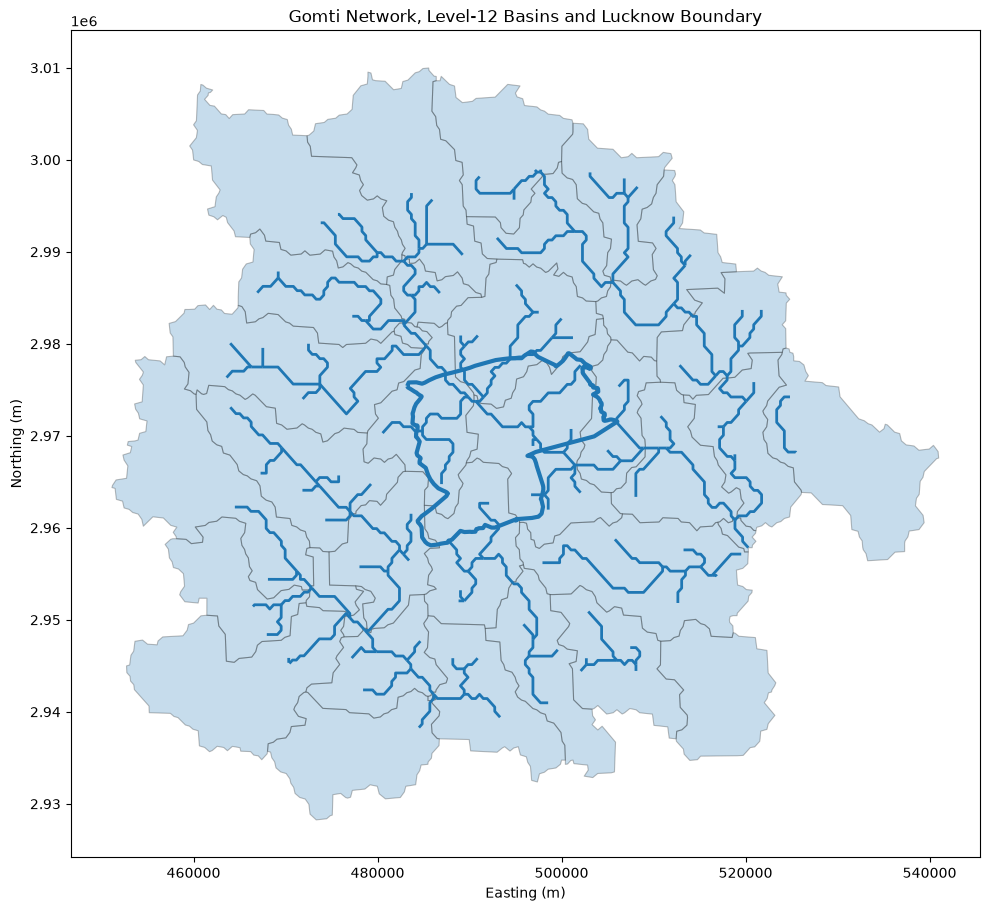

<Figure size 640x480 with 0 Axes>

In [23]:
FIGURES_DIR = PROJECT_ROOT/"outputs"/"figures"/"notebook_01"
fig, ax = plt.subplots(figsize=(10, 10))

# Level-12 basins
gomti_basins.plot(
    ax=ax,
    alpha=0.25,
    edgecolor="black",
    linewidth=0.8
)

# Gomti river
gomti.plot(
    ax=ax,
    linewidth=2
)

# Lucknow boundary - emphasized
lucknow.boundary.plot(
    ax=ax,
    linewidth=3
)

ax.set_title("Gomti Network, Level-12 Basins and Lucknow Boundary")
ax.set_xlabel("Easting (m)")
ax.set_ylabel("Northing (m)")

plt.tight_layout()

plt.show()
plt.savefig(FIGURES_DIR/"Gomti Network, Level-12 Basins and Lucknow Boundary")

## 16. Identify Level-12 Basins Intersecting Lucknow

The 34 Level-12 basins associated with the Gomti river network extend
beyond the Lucknow urban boundary.

To identify the drainage units directly relevant to the city, we determine
which of these Level-12 basin polygons spatially intersect the Lucknow
city boundary.

This step reproduces and validates the basin selection previously
performed in QGIS.

In [24]:
lucknow_intersecting_basins = gomti_basins[
    gomti_basins.geometry.intersects(lucknow.geometry.iloc[0])
].copy()

print(
    "Level-12 basins intersecting Lucknow:",
    len(lucknow_intersecting_basins)
)

print("\nHYBAS_ID values:")
print(
    lucknow_intersecting_basins["HYBAS_ID"]
    .sort_values()
    .to_list()
)

Level-12 basins intersecting Lucknow: 6

HYBAS_ID values:
[4120865130, 4120865140, 4120871300, 4121478760, 4121478990, 4121480370]


## 17. Inspect the Six Level-12 Basins

The six Level-12 basins intersecting the Lucknow boundary are examined
using their HydroBASINS attributes.

The purpose is to understand their drainage hierarchy, contributing
area, and relationship to the Gomti network before defining the final
study area.

In [25]:
basin_columns = [
    "HYBAS_ID",
    "NEXT_DOWN",
    "NEXT_SINK",
    "MAIN_BAS",
    "DIST_SINK",
    "DIST_MAIN",
    "SUB_AREA",
    "UP_AREA",
    "PFAF_ID",
    "ORDER"
]

lucknow_intersecting_basins[basin_columns].sort_values("HYBAS_ID")

,HYBAS_ID,NEXT_DOWN,NEXT_SINK,MAIN_BAS,DIST_SINK,DIST_MAIN,SUB_AREA,UP_AREA,PFAF_ID,ORDER
76161,4120865130,4121478990,4120025450,4120025450,1493.5,1493.5,135.1,9144.8,452456750300,3
76162,4120865140,4121478990,4120025450,4120025450,1493.5,1493.5,163.7,163.8,452456750200,4
76157,4120871300,4120872900,4120025450,4120025450,1492.1,1492.1,118.6,306.0,452456298100,5
76067,4121478760,4120867990,4120025450,4120025450,1469.6,1469.6,88.2,9595.8,452456750120,3
76109,4121478990,4121478760,4120025450,4120025450,1478.3,1478.3,199.1,9507.5,452456750130,3
76139,4121480370,4120875590,4120025450,4120025450,1487.5,1487.5,139.8,139.9,452456296200,5


# 18. Notebook 01 Summary

## Purpose

This notebook established and validated the spatial data required for the
Phase 1 flood-susceptibility study of the Gomti River–influenced Lucknow
region.

## Key Results

- The Python geospatial environment was successfully configured.
- The prepared Gomti River network was loaded and validated.
- The selected Gomti network contains **160 HydroRIVERS reaches**.
- All 160 reaches have `MAIN_RIV = 41067217`, confirming the selected
  network represents the identified Gomti main-river system.
- The Gomti reaches are associated with **34 HydroBASINS Level-12 units**.
- All 34 `HYBAS_L12` identifiers were successfully matched with
  corresponding HydroBASINS polygons.
- The Lucknow city boundary, Gomti river network, and Level-12 basin data
  were confirmed to use **EPSG:32644**, allowing consistent spatial analysis.
- Of the 34 Gomti-associated Level-12 basins, **6 intersect the Lucknow
  city boundary**.
- These six Level-12 basin IDs were identified and their HydroBASINS
  attributes were inspected.
- Diagnostic maps were produced to understand the spatial relationship
  between the Gomti river network, drainage basins, and Lucknow.

## Study-Area Decision

The Level-12 basin analysis is used to establish the **hydrological context**
of the study area. The six basins intersecting Lucknow are **not treated as
the final catchment boundary**.

For the Phase 1 flood-susceptibility analysis, the study domain will be
defined as the **Gomti River–influenced Lucknow region using the prepared
Lucknow 20 km search area**, rather than incorrectly referring to the
municipal boundary or the six intersecting Level-12 polygons as the complete
Gomti catchment.

## Conclusion

The spatial datasets required for the next stage have been successfully
prepared, inspected, and validated. Notebook 01 is therefore complete.

The next notebook will focus on preparing the **topographic and hydrological
conditioning factors** required for flood-susceptibility analysis.